# Statistical Analysis

It allows you to delve into normality, statistical tests, correlations and relevant variables.

## Index

- [Statistical Analysis](#statistical-analysis)
  - [Index](#index)
  - [Loading libraries](#loading-libraries)
  - [Data Loading](#data-loading)
  - [Statistical Summary](#statistical-summary)
  - [Analisis de Normalidad](#analisis-de-normalidad)
    - [Hypothesis Testing](#hypothesis-testing)
    - [Shapiro-Wilk Test](#shapiro-wilk-test)
    - [Test D'Agostino-Pearson](#test-dagostino-pearson)
    - [Conclusion of normality analysis](#conclusion-of-normality-analysis)
  - [Correlation Analysis](#correlation-analysis)
    - [Correlation Map](#correlation-map)
    - [Influence of Categorical Variables (weather)](#influence-of-categorical-variables-weather)
    - [ANOVA test](#anova-test)
  - [Conclusions](#conclusions)

## Loading libraries

In [ ]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocess
from scipy import stats

# Configuración matplotlib
plt.style.use('ggplot') 

# Paths
import sys
import os
sys.path.append(os.path.abspath('../scripts'))
from paths import Paths

# Scripts
from visualization_scripts import distribution_grapher, qq_grapher, boxplots_grapher, corrmap_calc
from eda_scripts import unique_values
from stat_analysis_scripts import descriptive_statistics, summary_statistics, interpret_statistics, anova_test, posthoc_test

## Data Loading

In [2]:
## Dowload DataSet:

data = pd.read_csv(str(Paths.DATA_PROCESSED)+"/preprocess_data.csv")
print(data.head(5))

         date  precipitation  temp_max  temp_min  wind  weather  year  month  \
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle  2012      1   
1  2012-01-02           10.9      10.6       2.8   4.5     rain  2012      1   
2  2012-01-03            0.8      11.7       7.2   2.3     rain  2012      1   
3  2012-01-04           20.3      12.2       5.6   4.7     rain  2012      1   
4  2012-01-05            1.3       8.9       2.8   6.1     rain  2012      1   

   day  
0    1  
1    2  
2    3  
3    4  
4    5  


## Statistical Summary

In [3]:
numerical_columns = ['precipitation', 'temp_max', 'temp_min', 'wind']
df_num = data[numerical_columns]

In [4]:
df_num.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.205886
std,6.680194,7.349758,5.023004,1.344474
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,6.600000


In [5]:
resumen = summary_statistics(df_num)
print(resumen)

                count    media  mediana  moda  desviacion_estandar  minimo  \
precipitation  1461.0   3.0294      0.0   0.0               6.6802     0.0   
temp_max       1461.0  16.4391     15.6  11.1               7.3498    -1.6   
temp_min       1461.0   8.2348      8.3   6.1               5.0230    -7.1   
wind           1461.0   3.2059      3.0   2.6               1.3445     0.4   

                 q1    q3  maximo  asimetria  curtosis  
precipitation   0.0   2.8    55.9     3.5056   15.5222  
temp_max       10.6  22.2    35.6     0.2809   -0.6905  
temp_min        4.4  12.2    18.3    -0.2495   -0.6006  
wind            2.2   4.0     6.6     0.5642   -0.3302  


## Analisis de Normalidad

Pruebas de normalidad: Shapiro-Wilk, Kolmogorov-Smirnov o Anderson-Darling

- Visual:

- Histograma + curva normal

- Q-Q plots (gráficos de cuantiles)

### Hypothesis Testing
The Shapiro-Wilk test and the D'Agostino K-squared test are two of the most commonly used hypothesis tests for analyzing normality. In both, the null hypothesis is that the data come from a normal distribution.

### Shapiro-Wilk Test
The p-value of these tests indicates the probability of obtaining data similar to those observed if they truly come from a population with a normal distribution with the same mean and standard deviation. Therefore, if the p-value is less than a certain value (typically 0.05), then there is sufficient evidence to reject normality.

The Shapiro-Wilk test is not recommended when there are large amounts of data (more than 50) due to its high sensitivity to small deviations from normality.

In [6]:
# Shapiro-Wilk test
# ==============================================================================

for idx, column in enumerate(df_num):
    if df_num[column].count() < 50:
        print(f"SI cumple criterio de datos, Cantidad de datos = {df_num[column].count()}")
    else:
        print(f"NO cumple criterio de datos, Cantidad de datos = {df_num[column].count()}")

    shapiro_test = stats.shapiro(df_num[column])
    print(shapiro_test)
    print()

NO cumple criterio de datos, Cantidad de datos = 1461
ShapiroResult(statistic=np.float64(0.5205678306061179), pvalue=np.float64(1.1627273421175324e-52))

NO cumple criterio de datos, Cantidad de datos = 1461
ShapiroResult(statistic=np.float64(0.9802632635945632), pvalue=np.float64(2.8459439764287343e-13))

NO cumple criterio de datos, Cantidad de datos = 1461
ShapiroResult(statistic=np.float64(0.9837458888294452), pvalue=np.float64(9.109896771574584e-12))

NO cumple criterio de datos, Cantidad de datos = 1461
ShapiroResult(statistic=np.float64(0.9630330789514168), pvalue=np.float64(7.799634324676515e-19))



### Test D'Agostino-Pearson
A test that is not sensitive to ties is the D'Agostino-Pearson normality test.

This test is implemented in the dagoTest function of the fBasics package. It quantifies how different the sample's skewness and kurtosis (two statistical parameters related to the shape of the graph of the sample density function) are from those expected in a normal distribution, and summarizes this discrepancy in a p-value with the usual meaning.

To apply this test, the sample size must be at least 20.

Therefore, we can only apply this test to the data sample corresponding to the Student's t distribution:

In [7]:
for idx, column in enumerate(df_num):    
    k2, p_value = stats.normaltest(df_num[column])
    print(f"Para datos {column}  ̣\nEstadístico = {k2}, p-value = {p_value}\n")

Para datos precipitation  ̣
Estadístico = 1106.3581061502698, p-value = 5.71991723813834e-241

Para datos temp_max  ̣
Estadístico = 90.89172197551865, p-value = 1.832792705405349e-20

Para datos temp_min  ̣
Estadístico = 61.37766489360388, p-value = 4.699042925532965e-14

Para datos wind  ̣
Estadístico = 77.61072616887533, p-value = 1.4029588861655434e-17



### Conclusion of normality analysis

There are no statistical indicators that establish the existence of normality in the data analyzed or, in other words, there is significant evidence of non-normality.

## Correlation Analysis

### Correlation Map

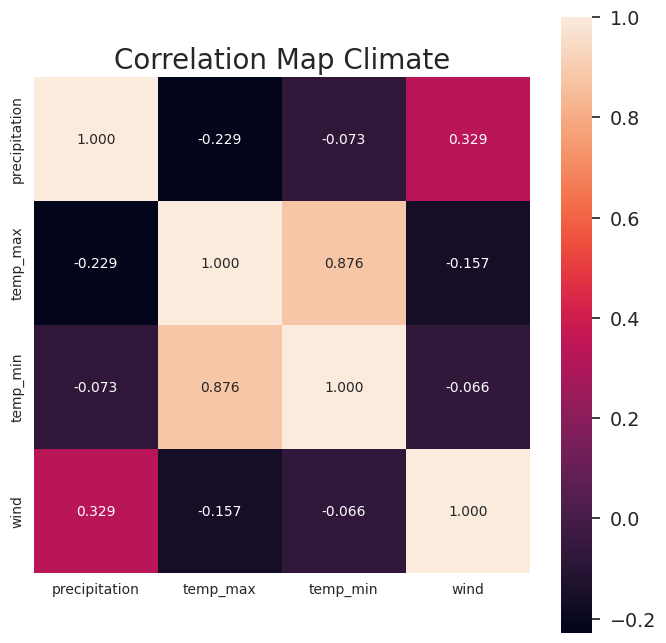

In [8]:
corrmap_calc(df_num,n_decimal = 3, title_graph = [True,"Correlation Map Climate",20] )


### Influence of Categorical Variables (weather)

In [9]:
uniqueval_df = pd.DataFrame(unique_values(data[['weather']])[0])["Un_Value weather"]
print(uniqueval_df)

0       rain
1        sun
2        fog
3    drizzle
4       snow
Name: Un_Value weather, dtype: object


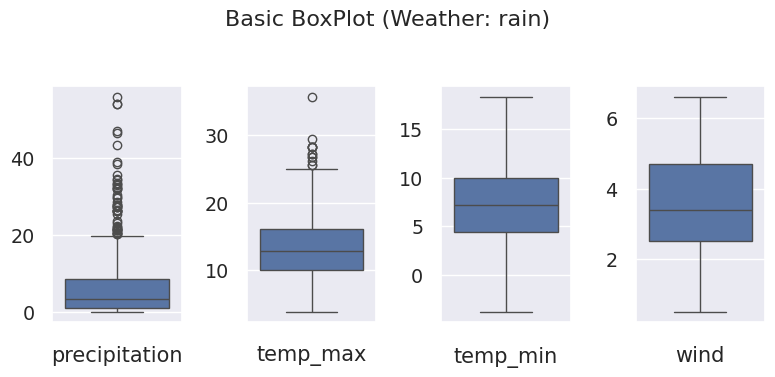

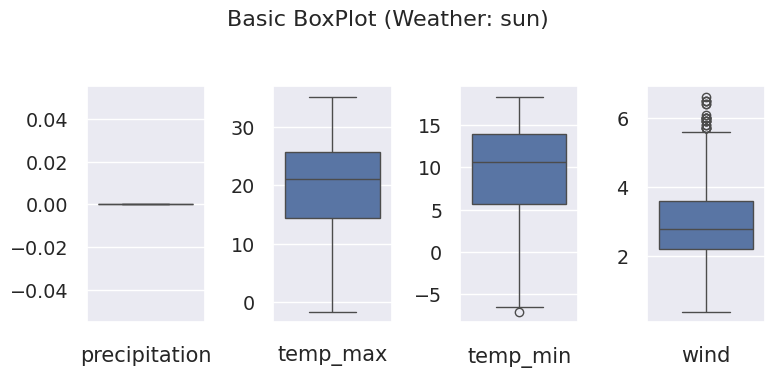

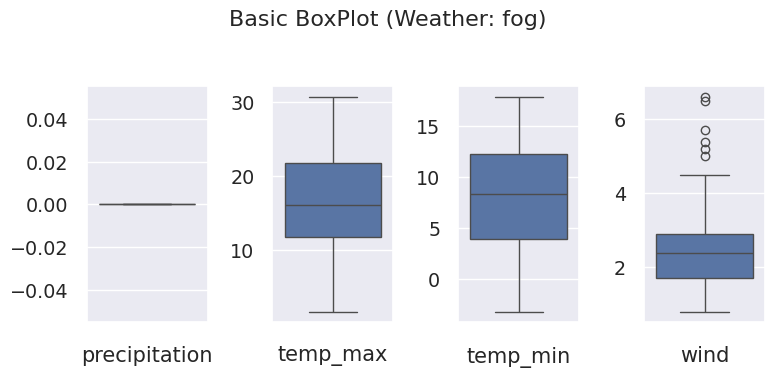

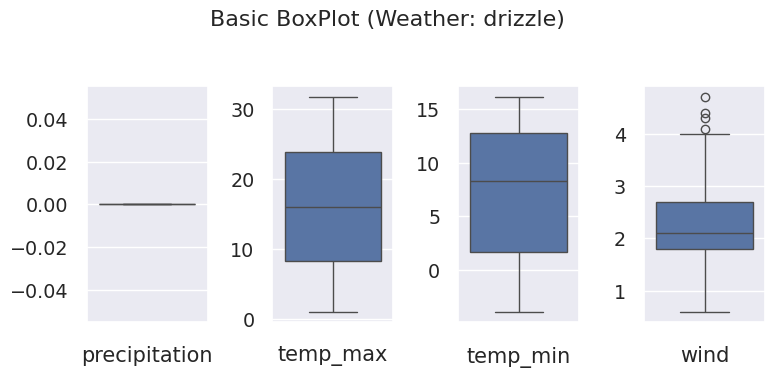

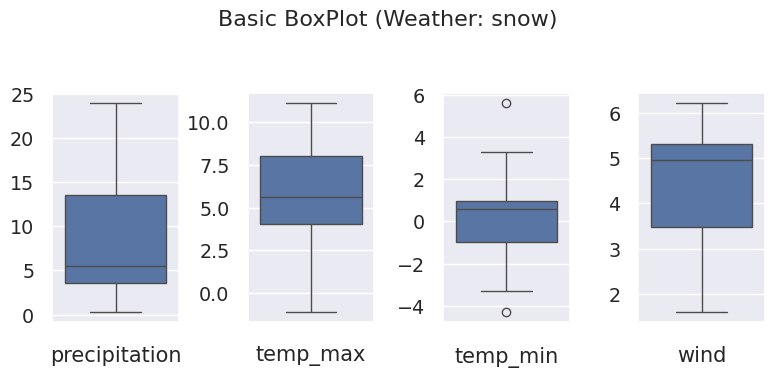

In [10]:
for i in uniqueval_df:
    df_vars = data[data['weather'] == i][['precipitation', 'temp_max', 'temp_min', 'wind']]
    boxplots_grapher(df_vars, [8,4], f"Basic BoxPlot (Weather: {i})")

### ANOVA test

In [11]:
df_vars = data[['precipitation', 'temp_max', 'temp_min', 'wind','weather']]

ANÁLISIS ANOVA: wind vs weather

📊 ESTADÍSTICAS DESCRIPTIVAS POR GRUPO:
--------------------------------------------------
         count    mean  median     std  min  max
weather                                         
drizzle     53  2.3679    2.10  0.9114  0.6  4.7
fog        101  2.4812    2.40  1.1966  0.8  6.6
rain       641  3.6016    3.40  1.4362  0.5  6.6
snow        26  4.3731    4.95  1.3806  1.6  6.2
sun        640  2.9459    2.80  1.1298  0.4  6.6

🔍 PRUEBA ANOVA DE UNA VÍA:
--------------------------------------------------
Estadístico F: 41.3609
p-value: 0.0000

Interpretación (α = 0.05):
✅ RECHAZAMOS H₀: Hay diferencias significativas entre grupos
   Las medias de los grupos son estadísticamente diferentes

🔧 VERIFICACIÓN DE SUPUESTOS:
--------------------------------------------------
1. Normalidad por grupo:
   drizzle: p = 0.0190 ❌
   rain: p = 0.0000 ❌
   sun: p = 0.0000 ❌
   snow: p = 0.0244 ❌
   fog: p = 0.0000 ❌
2. Homocedasticidad (Levene): p = 0.0000 ❌

📏 TAMA

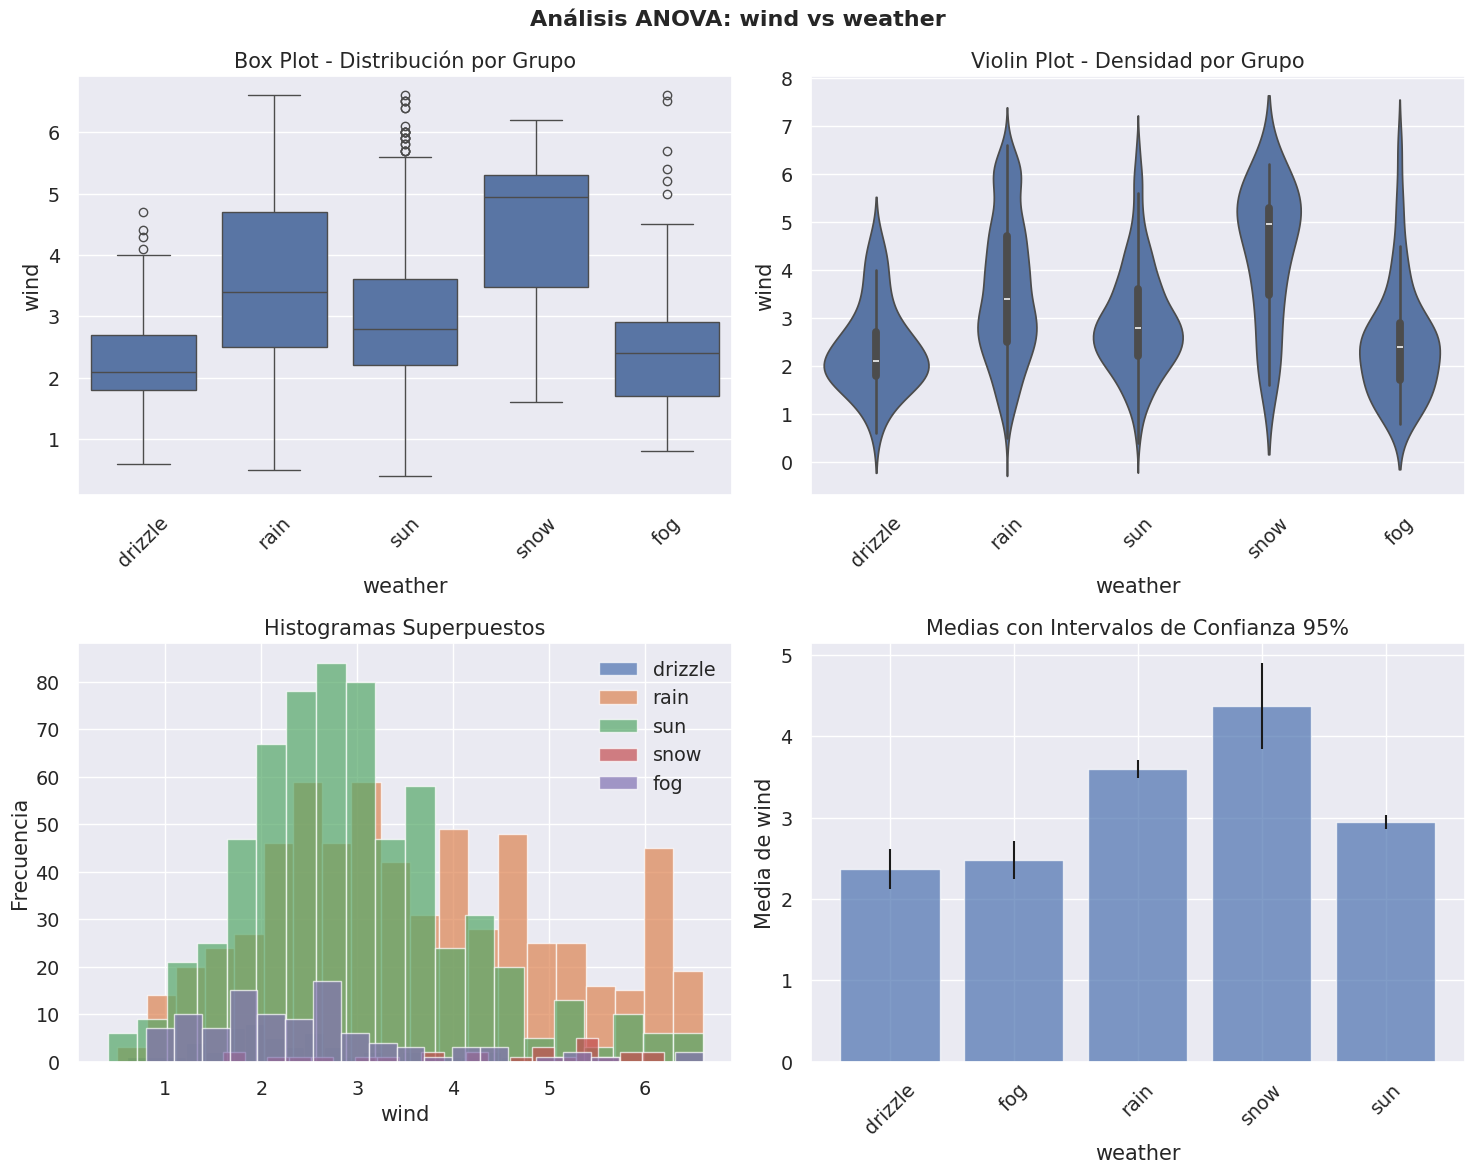


🔍 ANÁLISIS POST-HOC (Tukey HSD):
--------------------------------------------------
Comparaciones pareadas:
Grupo 1         Grupo 2         Diferencia   p-value    Significativo
----------------------------------------------------------------------
drizzle         rain            1.2336       0.0000     ✅
drizzle         sun             0.5780       0.0135     ✅
drizzle         snow            2.0052       0.0000     ✅
drizzle         fog             0.1133       0.9850     ❌
rain            sun             0.6556       0.0000     ✅
rain            snow            0.7715       0.0214     ✅
rain            fog             1.1204       0.0000     ✅
sun             snow            1.4271       0.0000     ✅
sun             fog             0.4647       0.0062     ✅
snow            fog             1.8919       0.0000     ✅


In [12]:
anova_test(df_vars, 'wind', 'weather')
posthoc_test(df_vars, 'wind', 'weather')

ANÁLISIS ANOVA: temp_max vs weather

📊 ESTADÍSTICAS DESCRIPTIVAS POR GRUPO:
--------------------------------------------------
         count     mean  median     std  min   max
weather                                           
drizzle     53  15.9264    16.1  8.8120  1.1  31.7
fog        101  16.7574    16.1  6.7747  1.7  30.6
rain       641  13.4546    12.8  4.9730  3.9  35.6
snow        26   5.5731     5.6  3.1092 -1.1  11.1
sun        640  19.8619    21.1  7.6983 -1.6  35.0

🔍 PRUEBA ANOVA DE UNA VÍA:
--------------------------------------------------
Estadístico F: 94.8387
p-value: 0.0000

Interpretación (α = 0.05):
✅ RECHAZAMOS H₀: Hay diferencias significativas entre grupos
   Las medias de los grupos son estadísticamente diferentes

🔧 VERIFICACIÓN DE SUPUESTOS:
--------------------------------------------------
1. Normalidad por grupo:
   drizzle: p = 0.0264 ❌
   rain: p = 0.0000 ❌
   sun: p = 0.0000 ❌
   snow: p = 0.8411 ✅
   fog: p = 0.0719 ✅
2. Homocedasticidad (Levene): p 

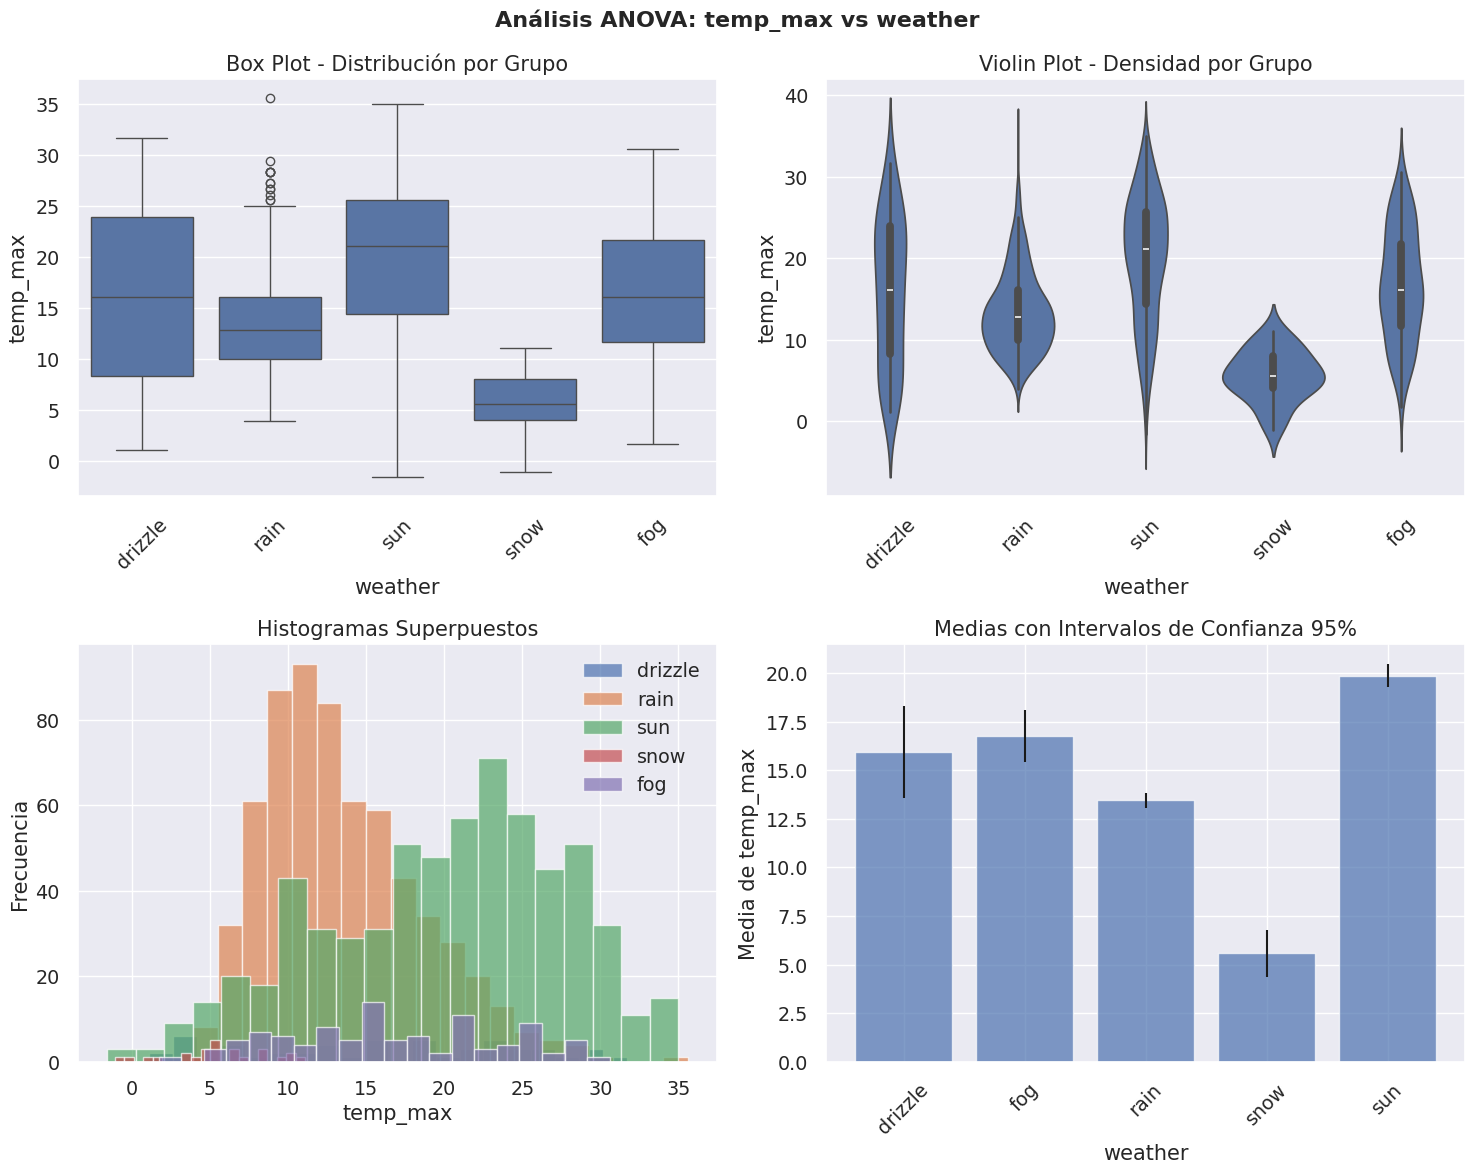


🔍 ANÁLISIS POST-HOC (Tukey HSD):
--------------------------------------------------
Comparaciones pareadas:
Grupo 1         Grupo 2         Diferencia   p-value    Significativo
----------------------------------------------------------------------
drizzle         rain            2.4718       0.0641     ❌
drizzle         sun             3.9355       0.0003     ✅
drizzle         snow            10.3533      0.0000     ✅
drizzle         fog             0.8310       0.9452     ❌
rain            sun             6.4073       0.0000     ✅
rain            snow            7.8815       0.0000     ✅
rain            fog             3.3028       0.0000     ✅
sun             snow            14.2888      0.0000     ✅
sun             fog             3.1044       0.0001     ✅
snow            fog             11.1843      0.0000     ✅


In [13]:
anova_test(df_vars, 'temp_max', 'weather')
posthoc_test(df_vars, 'temp_max', 'weather')

## Conclusions

EN:

1. The numerical variables exhibit high variability, especially precipitation, which has a low mean (≈3 mm) but extreme maximum values (up to 55.9 mm), with a highly skewed distribution and high kurtosis.

2. Normality tests (Shapiro-Wilk and D'Agostino-Pearson) indicate that none of the variables follow a normal distribution, with p-values < 0.05 in all cases.

3. There is only a moderate correlation between temp_max and temp_min, as expected. The other variables do not show strong correlations.

4. The ANOVA analysis revealed statistically significant differences in the means of wind and temp_max according to weather. For example, wind speed is higher on snowy days, and the maximum temperature differs significantly between sunny and snowy climates.

5. Although significant differences were found, the assumptions of normality and homoscedasticity are not met, so the results of the ANOVA should be interpreted with caution and complemented with non-parametric analyses if greater robustness is desired.

ES:

1. Las variables numéricas presentan una alta variabilidad, especialmente precipitation, que tiene una media baja (≈3 mm) pero valores máximos extremos (hasta 55.9 mm), con una distribución altamente asimétrica y curtosis elevada.

2. Las pruebas de normalidad (Shapiro-Wilk y D'Agostino-Pearson) indican que ninguna de las variables sigue una distribución normal ya que p-value < 0.05 en todos los casos.

3. Solo existe una correlación moderada entre temp_max y temp_min, como era de esperarse. Las demás variables no presentan correlaciones fuertes.

4. El análisis ANOVA reveló diferencias estadísticamente significativas en las medias de wind y temp_max según el tipo de clima (weather). Por ejemplo, la velocidad del viento es mayor en días con nieve, y la temperatura máxima difiere fuertemente entre climas soleados y nevados.

5. Aunque se encontraron diferencias significativas, los supuestos de normalidad y homocedasticidad no se cumplen, por lo que se deben interpretar los resultados del ANOVA con precaución y complementar con análisis no paramétricos si se desea más robustez.